In [ ]:
# PET VAE Model Evaluation: SSIM and PSNR Calculation
#
# This notebook calculates reconstruction quality metrics (SSIM and PSNR) for train/validation/test sets.
# Main purposes:
# 1. Load trained model
# 2. Calculate SSIM and PSNR metrics for all datasets
# 3. Save metrics to text files for later analysis
# 4. Visualize metric distributions with box plots
#
# ⚠️ NOTE: This script processes all slices and may take significant time to run

import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
#from torchvision.utils import save_image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import seaborn as sns

from addl_models_bimodel_pytorch import VAE_1modality_PET

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 51888 bytes to addl_models_bimodel_pytorch.py


In [3]:
plt.rcParams.update({
    "font.size": 12,              # base font size
    "axes.titlesize": 14,         # title font
    "axes.labelsize": 13,         # x and y labels
    "xtick.labelsize": 11,        # x ticks
    "ytick.labelsize": 11,        # y ticks
    "legend.fontsize": 11,        # legend
})

#plt.rcParams['figure.constrained_layout.use'] = True

In [ ]:
# EXPERIMENT CONFIGURATION
# Date identifier for this evaluation run (should match training date)
date = '26_05_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [ ]:
# Load metadata containing image paths and sample information
# This metadata is used to create train/validation/test datasets
meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv',header=[0], index_col=[0])
meta2.reset_index(drop=True, inplace = True)

In [6]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1


In [ ]:
# DATA PARTITIONING: Split data into train/validation/test sets
# 
# Split structure:
# - Train: First 80% of train set (64% of total data)
# - Validation: Last 20% of train set (16% of total data)  
# - Test: Remaining 20% of total data

train_size = 0.8
train_end = int(len(meta2)*train_size)

data_train = meta2[:train_end]
data_test = meta2[train_end:]

data_partition = dict()

# Split train set further into train (80%) and validation (20%)
t = int(0.8*np.shape(data_train)[0])
v = int(0.2*np.shape(data_train)[0])  # Not used, calculated for reference

# Create partitions using sequential indexing
# WARNING: Sequential split without shuffle can cause data leakage
data_partition['train'] = meta2.loc[:t,:].reset_index(drop=True)
data_partition['validation'] = meta2.loc[t+1:train_end,:].reset_index(drop=True)
data_partition['test'] = meta2.loc[train_end+1:,:].reset_index(drop=True)

data_partition['all'] = meta2.loc[:,:].reset_index(drop=True)


In [8]:
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']

p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']

p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']

p_quant999 = stat['p_quant999']
m_quant999 = stat['m_quant999']

p_std = stat['p_std']
m_std = stat['m_std']

p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

p_min_clip = stat['p_mim_clip']
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [ ]:
class PETSliceDataset(Dataset):
    """
    PyTorch Dataset for 2D slices extracted from PET scans.
    
    This dataset extracts 2D slices from 3D PET volumes along a specified axis.
    Used for calculating SSIM and PSNR metrics on train/validation/test sets.
    
    Parameters:
    - list_IDs_pet: List of file paths to PET scan files
    - slice_axis: Axis along which to extract slices (0=sagittal, 1=coronal, 2=axial)
    - brain_mask: Binary mask to apply to slices
    - pet_minimum/maximum: Min/max values for normalization (from training statistics)
    - pet_quant: Quantile threshold for clipping (default: 99.9th percentile)
    """
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant= m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        self.list_IDs_pet = list_IDs_pet
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm

            # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

            # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        
        pet_norm = np.clip(pet_norm, 0, 1)
        
        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    
    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [10]:
# creating PET datasets 
train_dataset = PETSliceDataset(list_IDs_pet = data_partition['train']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETSliceDataset(list_IDs_pet = data_partition['validation']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETSliceDataset(list_IDs_pet = data_partition['test']['PET_PATH_normalised'], brain_mask = brain_mask)


In [11]:
# creating dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=1,
                        shuffle=False, num_workers=1)

validation_dataloader = DataLoader(validation_dataset, batch_size=1,
                        shuffle=False, num_workers=1)

test_dataloader = DataLoader(test_dataset, batch_size=1,
                        shuffle=False, num_workers=1)

In [ ]:
# MODEL LOADING
# Load the best trained model checkpoint for evaluation
# NOTE: Model is loaded on CPU to avoid GPU memory issues during evaluation
# Alternative GPU loading (commented out):
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#model_up=torch.load(path+"/best_model.pth").to(device)

model_up=torch.load(path+"/best_model.pth", map_location=torch.device('cpu'))
model_up.eval()  # Set model to evaluation mode

VAE_1modality_PET(
  (conv): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_mean): Linear(in_features=262144, out_features=64, bias=True)
  (dense_log_var): Linear(in_features=262144, out_features=64, bias=True)
  (dense): Linear(in_features=64, out_features=262144, bias=True)
  (deconv): Sequential(
    (0): DeconvBlock(
      (deconv): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): DeconvBlock(
      (deconv): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (2): DeconvBlock(

In [ ]:
def metrics_calculation(dataloader):
    """
    Calculate reconstruction quality metrics (SSIM and PSNR) for all samples in dataloader.
    
    Process:
    1. Process each batch through the model
    2. Calculate SSIM and PSNR between original and reconstructed images
    3. Skip empty slices (sum <= 0) and mark as NaN
    
    ⚠️ NOTE: Requires 'device' variable to be defined (CPU or GPU)
    
    Parameters:
    - dataloader: DataLoader containing evaluation samples
    
    Returns:
    - ssims: List of SSIM values (one per slice)
    - psnrs: List of PSNR values (one per slice)
    """
    ssims = []
    psnrs = []
    
    # Alternative implementation (commented out) - processes full volumes slice by slice
    # Current implementation processes batches of slices
    
    for batch_idx, data in enumerate(dataloader):
        # Prepare batch data
        # NOTE: 'device' variable must be defined (CPU or GPU)
        data_batch_train = data['image'].float().to(device)
        
        # Forward pass: reconstruct images
        image_recon_train = model_up(data_batch_train)

        # Convert to numpy for metric calculation
        orig_scan = data_batch_train.detach().cpu().numpy()
        recon_scan = image_recon_train[0].detach().cpu().numpy()  # Extract reconstruction (first element)

        # Calculate metrics only for non-empty slices
        if orig_scan.sum() > 0:
            # SSIM: Structural Similarity Index (range: -1 to 1, higher is better)
            ssims.append(float(ssim(orig_scan[0][0], recon_scan[0][0], data_range=1)))
            # PSNR: Peak Signal-to-Noise Ratio (higher is better, typically 20-50 dB)
            psnrs.append(float(psnr(orig_scan[0][0], recon_scan[0][0], data_range=1)))
        else:
            # Mark empty slices as NaN
            ssims.append(np.nan)
            psnrs.append(np.nan)
        
        print(batch_idx)  # Progress indicator
        
    return ssims, psnrs

In [ ]:
# DEBUG/TEST CELL - Calculate metrics for subset of test samples
# Uncomment to test metrics calculation on first 182 slices (one full volume)
# This was used for testing/debugging before running full evaluation
'''from torch.utils.data import Subset, DataLoader
subset_indices = list(range(182))  # First 182 slices (one full volume)
test_subset = Subset(test_dataset, subset_indices)
test_dataloader = DataLoader(test_subset, batch_size=1, shuffle=False, num_workers=0)

ssim_train, psnr_train = metrics_calculation(test_dataloader)'''

In [ ]:
# MAIN METRICS CALCULATION - Calculate SSIM and PSNR for all datasets
# ⚠️ NOTE: This requires 'device' variable to be defined 
# This process can take significant time - run on cluster for large datasets
#
# Process:
# 1. Calculate metrics for train set
# 2. Calculate metrics for validation set
# 3. Calculate metrics for test set
# 4. Save all metrics to text files

# Define device (required for metrics_calculation function)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print('I am starting metrics calculation')

# TRAIN SET METRICS
ssim_train = []
psnr_train = []
ssim_train, psnr_train = metrics_calculation(train_dataloader)
np.savetxt("ssim_train_masked.txt", ssim_train)
np.savetxt("psnr_train_masked.txt", psnr_train)
print('train metrics calculated')

# VALIDATION SET METRICS
ssim_val = []
psnr_val = []
ssim_val, psnr_val = metrics_calculation(validation_dataloader)
np.savetxt("ssim_val_masked.txt", ssim_val)
np.savetxt("psnr_val_masked.txt", psnr_val)
print('validation metrics calculated')

# TEST SET METRICS
ssim_test = []
psnr_test = []
ssim_test, psnr_test = metrics_calculation(test_dataloader)
np.savetxt("ssim_test_masked.txt", ssim_test)
np.savetxt("psnr_test_masked.txt", psnr_test)
print('test metrics calculated')

## POST-ANALYSIS: Load and Visualize Metrics
# This section loads saved metrics and creates visualizations

In [ ]:
# LOAD METRICS WITH NaN FILTERING
# Load saved metrics and remove NaN values (empty slices)
# This is the standard way to load metrics after calculation



# Load and filter train metrics
ssim_train = np.loadtxt("ssim_train_masked.txt")
ssim_train = ssim_train[~np.isnan(ssim_train)]  # Remove NaN values (empty slices)
psnr_train = np.loadtxt("psnr_train_masked.txt")
psnr_train = psnr_train[~np.isnan(psnr_train)]

# Load and filter validation metrics
ssim_val = np.loadtxt("ssim_val_masked.txt")
ssim_val = ssim_val[~np.isnan(ssim_val)]
psnr_val = np.loadtxt("psnr_val_masked.txt")
psnr_val = psnr_val[~np.isnan(psnr_val)]

# Load and filter test metrics
ssim_test = np.loadtxt("ssim_test_masked.txt")
ssim_test = ssim_test[~np.isnan(ssim_test)]
psnr_test = np.loadtxt("psnr_test_masked.txt")
psnr_test = psnr_test[~np.isnan(psnr_test)]

# Verify loaded metrics
print("Train SSIM shape:", ssim_train.shape)
print("Validation PSNR sample:", psnr_val[:5])

Train SSIM shape: (304418,)
Validation PSNR sample: [39.93318122 33.40666598 40.64357357 40.51523222 40.54343489]


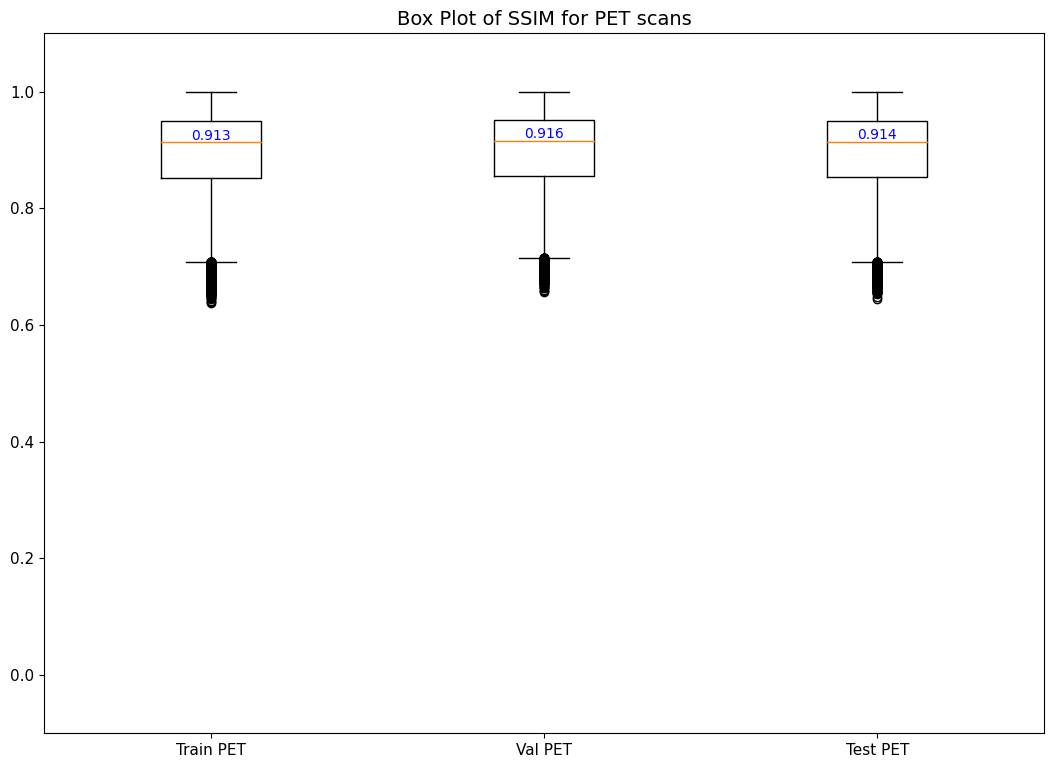

In [ ]:
# VISUALIZE SSIM METRICS: Box plot comparing train/validation/test sets
# This visualization helps compare reconstruction quality across datasets

import matplotlib.pyplot as plt
data = [ssim_train, ssim_val, ssim_test]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of SSIM for PET scans')

# Create box plot
bp = ax.boxplot(data)

# Add labels
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Set y-axis range (SSIM ranges from -1 to 1, typically 0.4-1.0 for good reconstructions)
ax.set_ylim(-0.1, 1.1)

# Add median annotations
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    ax.text(i, median_value, f'{median_value:.3f}', ha='center', va='bottom', fontsize=10, color='blue')

plt.savefig(path+'/SSIM_boxplots_all_'+date+'.png', bbox_inches='tight') 
plt.show()

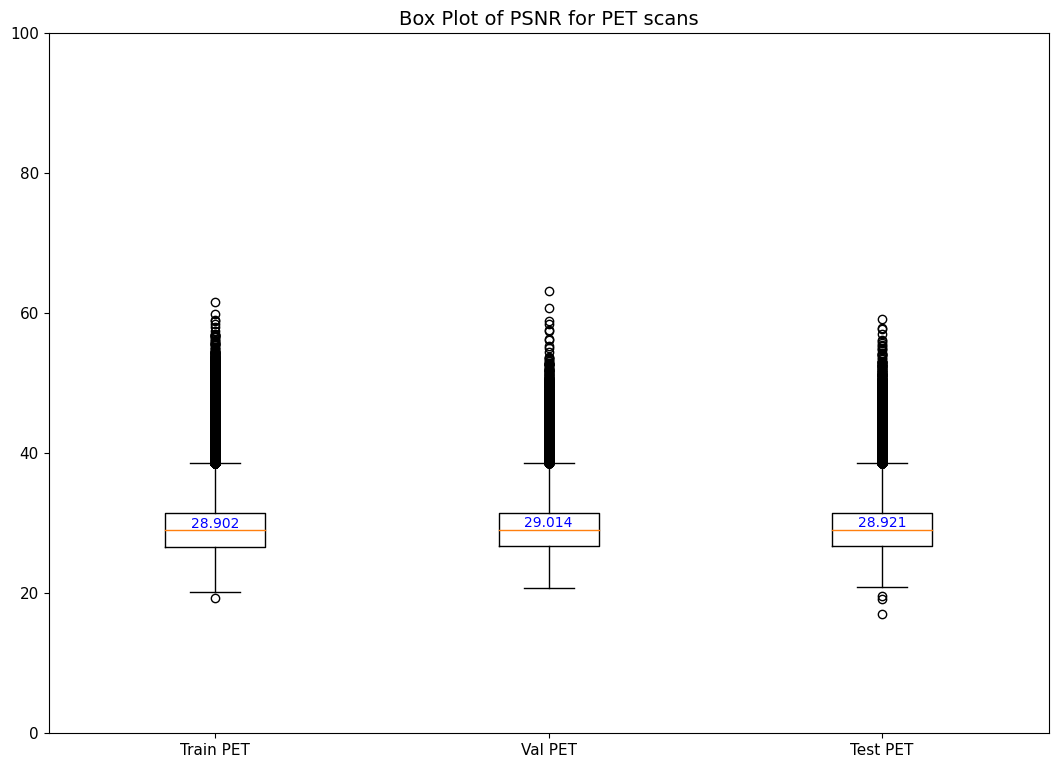

In [ ]:
# VISUALIZE PSNR METRICS: Box plot comparing train/validation/test sets
# This visualization helps compare reconstruction quality across datasets

data = [psnr_train, psnr_val, psnr_test]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of PSNR for PET scans')

# Create box plot
bp = ax.boxplot(data)

# Add labels
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Set y-axis range (PSNR typically ranges from 20-50 dB for good reconstructions)
ax.set_ylim(-0.1, 100)

# Add median annotations
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    ax.text(i, median_value, f'{median_value:.3f}', ha='center', va='bottom', fontsize=10, color='blue')

# Save figure (currently commented out - uncomment to save)
#plt.savefig(path+'/PSNR_boxplots_all_'+date+'.png', bbox_inches='tight') 
plt.show()

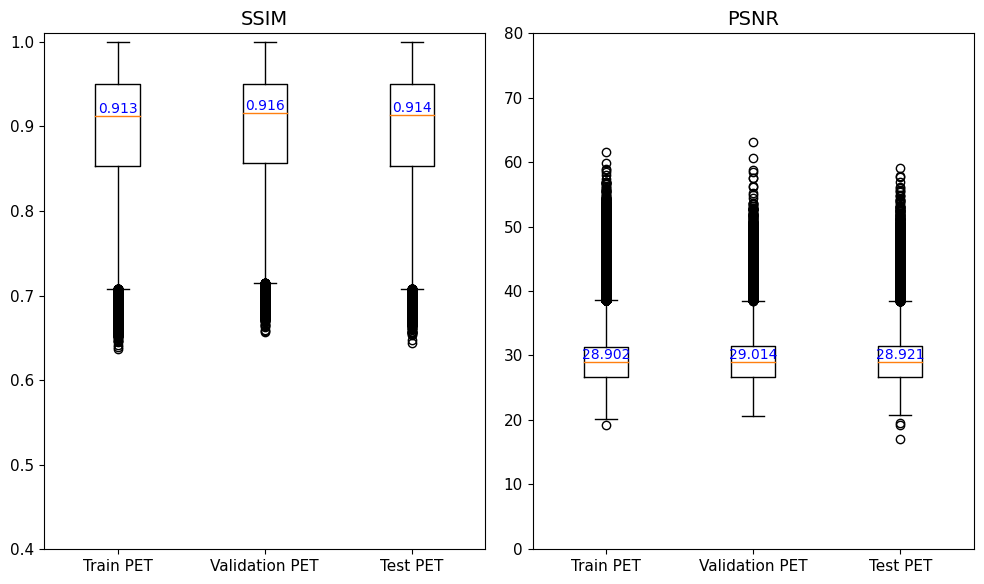

In [ ]:

# Data
ssim_data = [ssim_train, ssim_val, ssim_test]
psnr_data = [psnr_train, psnr_val, psnr_test]
labels = ['Train PET', 'Validation PET', 'Test PET']

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# --- SSIM subplot ---
axes[0].set_title('SSIM')
bp1 = axes[0].boxplot(ssim_data)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.4, 1.01)

for i, dataset in enumerate(ssim_data, start=1):
    median_value = np.median(dataset)
    axes[0].text(i, median_value, f'{median_value:.3f}', 
                 ha='center', va='bottom', fontsize=10, color='blue')

# --- PSNR subplot ---
axes[1].set_title('PSNR')
bp2 = axes[1].boxplot(psnr_data)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(-0.1, 80)

for i, dataset in enumerate(psnr_data, start=1):
    median_value = np.median(dataset)
    axes[1].text(i, median_value, f'{median_value:.3f}', 
                 ha='center', va='bottom', fontsize=10, color='blue')


plt.tight_layout()

#plt.savefig(path+'/SSIM_PSNR_boxplots_all_'+date+'.png', bbox_inches='tight', dpi=300) 
#plt.savefig(path+'/SSIM_PSNR_boxplots_all_'+date+'.svg', bbox_inches='tight', dpi=300) 


plt.show()


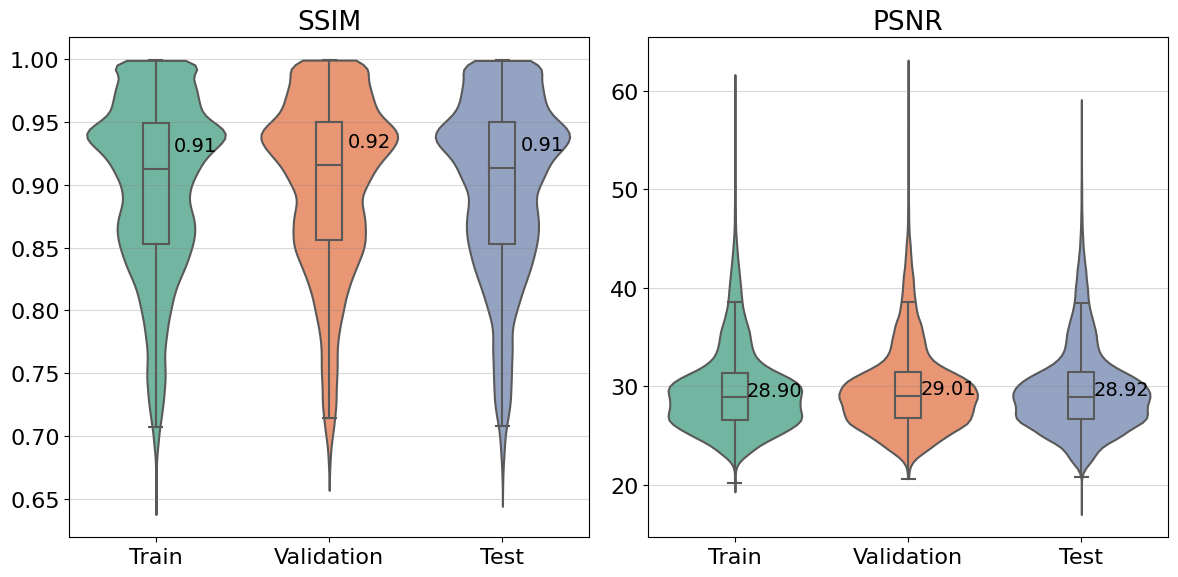

In [39]:
plt.rcParams.update({
    "font.size": 14,              # base font size
    "axes.titlesize": 19,         # title font
    "axes.labelsize": 18,         # x and y labels
    "xtick.labelsize": 16,        # x ticks
    "ytick.labelsize": 16,        # y ticks
    "legend.fontsize": 15        # legend
})


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Example datasets
ssim_data = [ssim_train, ssim_val, ssim_test]
psnr_data = [psnr_train, psnr_val, psnr_test]
labels = ['SSIM', 'PSNR']

datasets = [ssim_data, psnr_data]                 # list of lists

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

for ax, data, title in zip(axes, datasets, labels):

    # Violin plot
    sns.violinplot(data=data, inner=None, palette='Set2', cut=0, ax=ax)

    # Boxplot overlay
    sns.boxplot(
        data=data,
        width=0.15,
        showcaps=True,
        boxprops={'zorder': 2, 'facecolor': 'none'},
        showfliers=False,
        whiskerprops={'linewidth': 1.5},
        palette='Set2',
        ax=ax
    )

    # Add median labels
    for i, dataset in enumerate(data):
        median_value = np.median(dataset)
        ax.text(
            i+0.23, median_value-(median_value/100)+0.02,
            f'{median_value:.2f}',
            ha='center', va='bottom',
             color='black'
        )

    # Formatting
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Train', 'Validation', 'Test'])
    ax.set_title(title)
    #ax.set_ylabel("Value")
axes[0].grid(axis='y', color='grey', alpha=0.3, linewidth=0.8)
axes[1].grid(axis='y', color='grey', alpha=0.3, linewidth=0.8)

plt.tight_layout()

plt.savefig(path+'/SSIM_PSNR_boxplots_all_'+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
plt.savefig(path+'/SSIM_PSNR_boxplots_all_'+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  

plt.show()
